In [1]:
# Install these only if your environment does not already have them.
%pip install -q datasets transformers evaluate jiwer accelerate soundfile librosa matplotlib seaborn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 38.6 MB/s eta 0:00:00


In [2]:
from __future__ import annotations

import io
import re
from collections import Counter
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import soundfile as sf
from datasets import Audio, load_dataset
from IPython.display import Audio as IPythonAudio, display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 4)

print("Imports ready")


Imports ready


In [5]:
# Adjust this if you want another locale from MINDS-14.
DATASET_NAME = "PolyAI/minds14"
DATASET_CONFIG = "en-US"  # change to the locale you are using
TARGET_SAMPLING_RATE = 16000
RANDOM_SEED = 42

# Download (if not cached) or load MINDS-14 from Hugging Face Hub.
raw_dataset = load_dataset(DATASET_NAME, DATASET_CONFIG)
raw_dataset


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

en-US/train-00000-of-00001.parquet:   0%|          | 0.00/34.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/563 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id'],
        num_rows: 563
    })
})

In [6]:
for split_name, split_ds in raw_dataset.items():
    print(f"Split: {split_name}")
    print(f"  Rows: {len(split_ds)}")
    print(f"  Columns: {split_ds.column_names}")
    print(f"  Features: {split_ds.features}")
    print()

Split: train
  Rows: 563
  Columns: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id']
  Features: {'path': Value('string'), 'audio': Audio(sampling_rate=8000, decode=True, stream_index=None), 'transcription': Value('string'), 'english_transcription': Value('string'), 'intent_class': ClassLabel(names=['abroad', 'address', 'app_error', 'atm_limit', 'balance', 'business_loan', 'card_issues', 'cash_deposit', 'direct_debit', 'freeze', 'high_value_payment', 'joint_account', 'latest_transactions', 'pay_bill']), 'lang_id': ClassLabel(names=['cs-CZ', 'de-DE', 'en-AU', 'en-GB', 'en-US', 'es-ES', 'fr-FR', 'it-IT', 'ko-KR', 'nl-NL', 'pl-PL', 'pt-PT', 'ru-RU', 'zh-CN'])}



In [7]:
def detect_column(column_names, candidates):
    for candidate in candidates:
        if candidate in column_names:
            return candidate
    return None

train_columns = raw_dataset["train"].column_names
audio_col = detect_column(train_columns, ["audio", "speech", "waveform", "path"])
text_col = detect_column(train_columns, ["text", "transcription", "transcript", "sentence", "utterance", "normalized_text"])

print("Detected audio column:", audio_col)
print("Detected text column:", text_col)

if audio_col is None or text_col is None:
    raise ValueError(
        "Could not infer the audio/text columns automatically. "
        f"Available columns: {train_columns}"
    )

# Keep audio entries as metadata/path to avoid torchcodec decoding at row access time.
raw_dataset = raw_dataset.cast_column(audio_col, Audio(decode=False))
print("Configured audio column with decode=False")

def load_audio_record(audio_record, target_sr=None):
    path = audio_record.get("path")
    audio_bytes = audio_record.get("bytes")

    # MINDS-14 often provides valid bytes while path may be a non-resolvable filename.
    if audio_bytes is not None:
        waveform, sr = sf.read(io.BytesIO(audio_bytes))
    elif path:
        waveform, sr = sf.read(path)
    else:
        raise ValueError("Audio record has neither 'path' nor 'bytes'.")

    if waveform.ndim > 1:
        waveform = np.mean(waveform, axis=1)

    waveform = waveform.astype(np.float32)
    if target_sr is not None and sr != target_sr:
        waveform = librosa.resample(waveform, orig_sr=sr, target_sr=target_sr)
        sr = target_sr

    return waveform, sr


Detected audio column: audio
Detected text column: transcription
Configured audio column with decode=False


In [8]:
sample = raw_dataset["train"][0]
audio_sample = sample[audio_col]
text_sample = sample[text_col]

audio_array, audio_sr = load_audio_record(audio_sample)

print("Transcript:")
print(text_sample)
print()
print("Audio metadata:")
audio_metadata = {k: v for k, v in audio_sample.items() if k != "bytes"}
audio_metadata["bytes_length"] = len(audio_sample["bytes"]) if audio_sample.get("bytes") is not None else None
print(audio_metadata)

display(IPythonAudio(audio_array, rate=audio_sr))


Transcript:
I would like to set up a joint account with my partner

Audio metadata:
{'path': '602ba55abb1e6d0fbce92065.wav', 'bytes_length': 86758}


# EDA

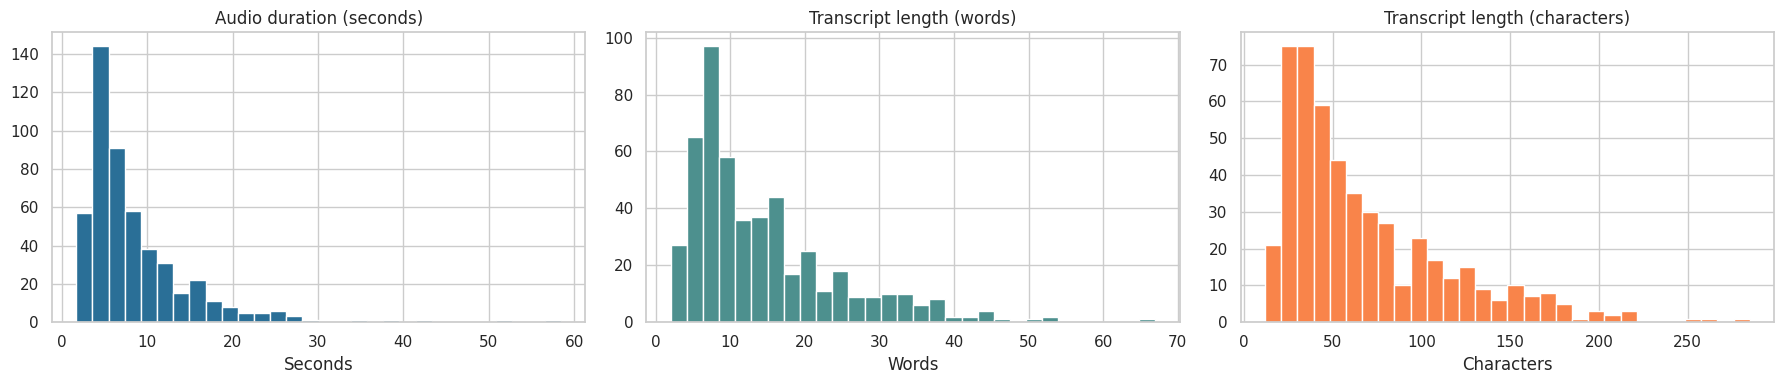

Duration summary
count    500.000000
mean       8.528764
std        6.460446
min        1.706625
25%        4.437375
50%        6.357313
75%       10.261344
max       58.453375
dtype: float64


In [9]:
eda_split = raw_dataset["train"]
eda_n = min(500, len(eda_split))
eda_subset = eda_split.select(range(eda_n))

durations = []
word_counts = []
char_counts = []

for row in eda_subset:
    audio_array, audio_sr = load_audio_record(row[audio_col], target_sr=TARGET_SAMPLING_RATE)
    durations.append(len(audio_array) / audio_sr)
    word_counts.append(len(str(row[text_col]).split()))
    char_counts.append(len(str(row[text_col])))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(durations, bins=30, color="#2a6f97")
axes[0].set_title("Audio duration (seconds)")
axes[0].set_xlabel("Seconds")

axes[1].hist(word_counts, bins=30, color="#4d908e")
axes[1].set_title("Transcript length (words)")
axes[1].set_xlabel("Words")

axes[2].hist(char_counts, bins=30, color="#f9844a")
axes[2].set_title("Transcript length (characters)")
axes[2].set_xlabel("Characters")

plt.tight_layout()
plt.show()

print("Duration summary")
print(pd.Series(durations).describe())


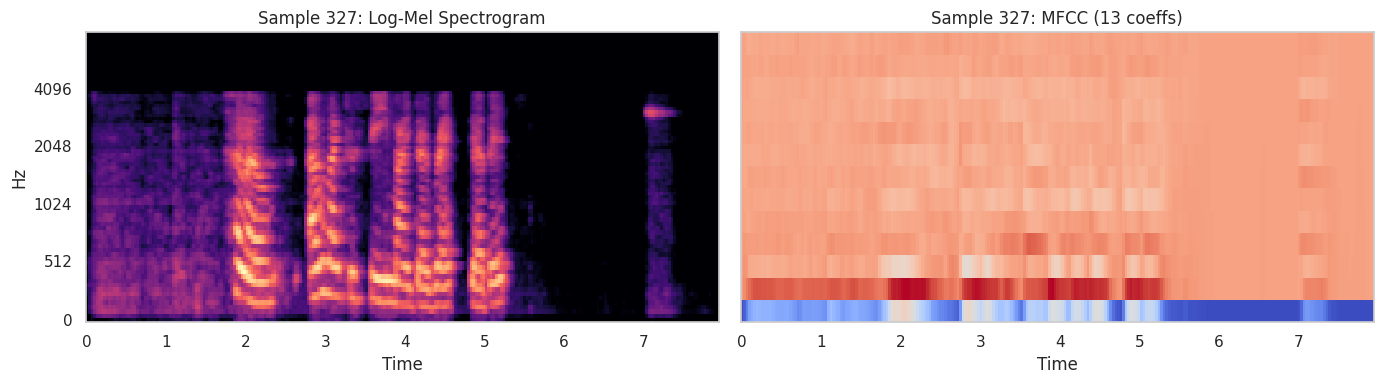

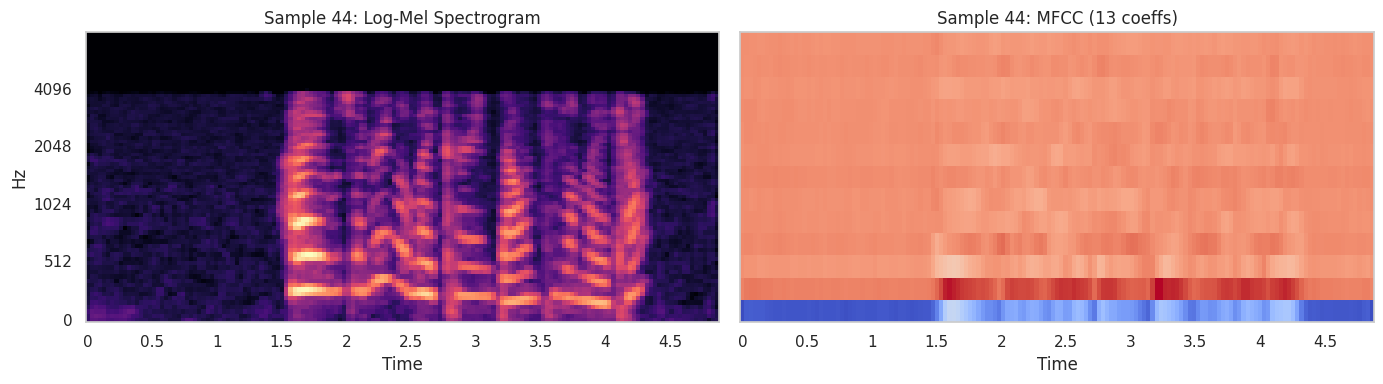

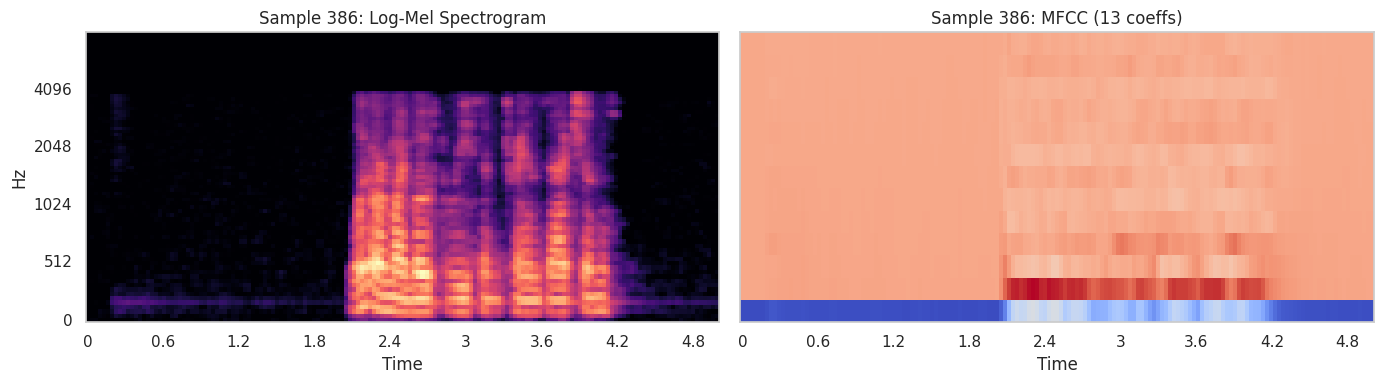

In [8]:
# Spectrogram + MFCC spot-check on a few random samples.
rng = np.random.default_rng(RANDOM_SEED)
sample_count = min(3, len(eda_subset))
random_ids = rng.choice(len(eda_subset), size=sample_count, replace=False)

for idx in random_ids:
    row = eda_subset[int(idx)]
    audio_array, audio_sr = load_audio_record(row[audio_col], target_sr=TARGET_SAMPLING_RATE)

    # Log-mel spectrogram.
    mel = librosa.feature.melspectrogram(y=audio_array, sr=audio_sr, n_mels=80)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # MFCC from log-mel style representation.
    mfcc = librosa.feature.mfcc(y=audio_array, sr=audio_sr, n_mfcc=13)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    librosa.display.specshow(mel_db, sr=audio_sr, x_axis="time", y_axis="mel", ax=axes[0])
    axes[0].set_title(f"Sample {idx}: Log-Mel Spectrogram")

    librosa.display.specshow(mfcc, sr=audio_sr, x_axis="time", ax=axes[1])
    axes[1].set_title(f"Sample {idx}: MFCC (13 coeffs)")

    plt.tight_layout()
    plt.show()


# Audio Preprocessing

In [10]:
# Phase 1 - Cell 1: Reload dataset with proper decoding enabled
# (Your EDA used decode=False for speed — now we re-enable for preprocessing)
from datasets import load_dataset, Audio
import numpy as np
import re

DATASET_NAME    = "PolyAI/minds14"
DATASET_CONFIG  = "en-US"
TARGET_SR       = 16000

# Re-load with decode=True so HuggingFace handles resampling automatically
dataset = load_dataset(DATASET_NAME, DATASET_CONFIG)
dataset = dataset.cast_column("audio", Audio(sampling_rate=TARGET_SR))

print("Dataset loaded with auto-resampling to 16kHz:")
print(dataset)

Dataset loaded with auto-resampling to 16kHz:
DatasetDict({
    train: Dataset({
        features: ['path', 'audio', 'transcription', 'english_transcription', 'intent_class', 'lang_id'],
        num_rows: 563
    })
})


In [11]:
# Phase 1 - Cell 2 (FIXED): Preprocessing functions

import numpy as np
import re

def normalize_audio(audio_array: np.ndarray) -> np.ndarray:
    """Scale audio to [-1, 1] range."""
    max_val = np.max(np.abs(audio_array))
    if max_val > 0:
        return audio_array / max_val
    return audio_array

def clean_transcription(text: str) -> str:
    """Lowercase, remove punctuation except apostrophes, collapse spaces."""
    text = text.lower().strip()
    text = re.sub(r"\s+", " ", text)
    return text

def preprocess(sample):
    # Extract the array FIRST before touching anything
    audio_array = np.array(sample["audio"]["array"], dtype=np.float32)

    # Return new keys directly — do NOT write back into sample["audio"]
    return {
        "input_array": normalize_audio(audio_array),
        "sampling_rate": sample["audio"]["sampling_rate"],
        "transcription": clean_transcription(sample["transcription"]),
    }

print("Functions defined — ready to apply.")

Functions defined — ready to apply.


In [12]:
# Phase 1 - Cell 3 (FIXED): Apply to all splits

dataset = dataset.map(
    preprocess,
    remove_columns=["audio"],   # drop the original locked audio column
    desc="Preprocessing audio"
)

# Sanity check
sample = dataset["train"][0]
arr = np.array(sample["input_array"], dtype=np.float32)

print("=== Sanity Check ===")
print(f"Sampling rate : {sample['sampling_rate']} Hz")
print(f"Audio dtype   : {arr.dtype}")
print(f"Audio max     : {arr.max():.4f}  (should be ~1.0)")
print(f"Audio min     : {arr.min():.4f}  (should be ~-1.0)")
print(f"Duration      : {len(arr) / TARGET_SR:.2f}s")
print(f"Transcription : {sample['transcription']}")
print(f"\nNew columns   : {dataset['train'].column_names}")

Preprocessing audio:   0%|          | 0/563 [00:00<?, ? examples/s]

=== Sanity Check ===
Sampling rate : 16000 Hz
Audio dtype   : float32
Audio max     : 1.0000  (should be ~1.0)
Audio min     : -0.6694  (should be ~-1.0)
Duration      : 10.84s
Transcription : i would like to set up a joint account with my partner

New columns   : ['path', 'transcription', 'english_transcription', 'intent_class', 'lang_id', 'input_array', 'sampling_rate']


In [13]:
# Phase 1 - Cell 4 (FIXED): Manually split train into train/validation/test
from datasets import DatasetDict

# Split: 80% train, 10% validation, 10% test
train_testval = dataset["train"].train_test_split(test_size=0.2, seed=42)
val_test      = train_testval["test"].train_test_split(test_size=0.5, seed=42)

dataset = DatasetDict({
    "train"      : train_testval["train"],
    "validation" : val_test["train"],
    "test"       : val_test["test"],
})

print("New splits:")
print(dataset)
print(f"\nTrain      : {len(dataset['train'])} samples")
print(f"Validation : {len(dataset['validation'])} samples")
print(f"Test       : {len(dataset['test'])} samples")

New splits:
DatasetDict({
    train: Dataset({
        features: ['path', 'transcription', 'english_transcription', 'intent_class', 'lang_id', 'input_array', 'sampling_rate'],
        num_rows: 450
    })
    validation: Dataset({
        features: ['path', 'transcription', 'english_transcription', 'intent_class', 'lang_id', 'input_array', 'sampling_rate'],
        num_rows: 56
    })
    test: Dataset({
        features: ['path', 'transcription', 'english_transcription', 'intent_class', 'lang_id', 'input_array', 'sampling_rate'],
        num_rows: 57
    })
})

Train      : 450 samples
Validation : 56 samples
Test       : 57 samples


--- Train stats ---
Min  : 1.71s
Max  : 58.45s
Mean : 8.73s
Clips > 10s : 125


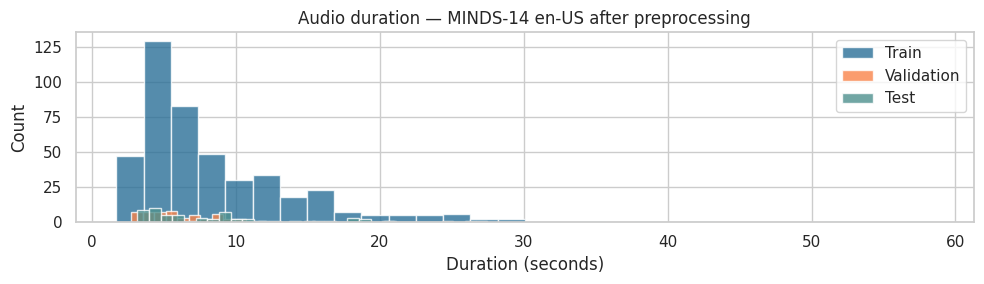

In [14]:
# Phase 1 - Cell 5: Duration distribution

import matplotlib.pyplot as plt

durations_train = [len(np.array(s["input_array"])) / TARGET_SR for s in dataset["train"]]
durations_val   = [len(np.array(s["input_array"])) / TARGET_SR for s in dataset["validation"]]
durations_test  = [len(np.array(s["input_array"])) / TARGET_SR for s in dataset["test"]]

print("--- Train stats ---")
print(f"Min  : {min(durations_train):.2f}s")
print(f"Max  : {max(durations_train):.2f}s")
print(f"Mean : {np.mean(durations_train):.2f}s")
print(f"Clips > 10s : {sum(d > 10 for d in durations_train)}")

plt.figure(figsize=(10, 3))
plt.hist(durations_train, bins=30, color="#2a6f97", edgecolor="white", alpha=0.8, label="Train")
plt.hist(durations_val,   bins=30, color="#f9844a", edgecolor="white", alpha=0.8, label="Validation")
plt.hist(durations_test,  bins=30, color="#4d908e", edgecolor="white", alpha=0.8, label="Test")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.title("Audio duration — MINDS-14 en-US after preprocessing")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# Phase 1 - Cell 6: Save preprocessed dataset with all 3 splits
SAVE_PATH = "/content/minds14_preprocessed"

dataset.save_to_disk(SAVE_PATH)

import os
print("Saved successfully!")
print("Splits saved:", os.listdir(SAVE_PATH))

Saving the dataset (0/1 shards):   0%|          | 0/450 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/56 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/57 [00:00<?, ? examples/s]

Saved successfully!
Splits saved: ['dataset_dict.json', 'train', 'test', 'validation']


# Feature Extraction

In [16]:
# Phase 2 - Cell 1 (FIXED): Load HuBERT processor
from transformers import Wav2Vec2Processor

MODEL_NAME = "facebook/hubert-large-ls960-ft"

processor = Wav2Vec2Processor.from_pretrained(MODEL_NAME)

print("Processor loaded!")
print(f"Model         : {MODEL_NAME}")
print(f"Sampling rate : {processor.feature_extractor.sampling_rate}")
print(f"Vocab size    : {processor.tokenizer.vocab_size}")

preprocessor_config.json:   0%|          | 0.00/212 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

Processor loaded!
Model         : facebook/hubert-large-ls960-ft
Sampling rate : 16000
Vocab size    : 32


In [17]:
# Phase 2 - Cell 2 (FIXED): See what the processor outputs on one sample
import numpy as np

sample = dataset["train"][0]
audio_array = np.array(sample["input_array"], dtype=np.float32)

# Process audio
inputs = processor(
    audio_array,
    sampling_rate=TARGET_SR,
    return_tensors="pt",
    padding=False,
)

# Process text label — call tokenizer directly (as_target_processor is deprecated)
label_ids = processor.tokenizer(
    sample["transcription"],
    return_tensors="pt",
)

print("=== Audio input ===")
print(f"input_values shape : {inputs.input_values.shape}")
print(f"dtype              : {inputs.input_values.dtype}")

print("\n=== Text label ===")
print(f"Transcription      : {sample['transcription']}")
print(f"Label IDs shape    : {label_ids.input_ids.shape}")
print(f"Label IDs          : {label_ids.input_ids}")

# Decode back to verify
decoded = processor.tokenizer.decode(label_ids.input_ids[0].tolist())
print(f"Decoded back       : {decoded}")

=== Audio input ===
input_values shape : torch.Size([1, 95574])
dtype              : torch.float32

=== Text label ===
Transcription      : hey honey can you tell me how much money i have in my account like what's the balance
Label IDs shape    : torch.Size([1, 85])
Label IDs          : tensor([[ 3,  3,  3,  4,  3,  3,  3,  3,  3,  4,  3,  3,  3,  4,  3,  3,  3,  4,
          3,  3,  3,  3,  4,  3,  3,  4,  3,  3,  3,  4,  3,  3,  3,  3,  4,  3,
          3,  3,  3,  3,  4,  3,  4,  3,  3,  3,  3,  4,  3,  3,  4,  3,  3,  4,
          3,  3,  3,  3,  3,  3,  3,  4,  3,  3,  3,  3,  4,  3,  3,  3,  3, 27,
          3,  4,  3,  3,  3,  4,  3,  3,  3,  3,  3,  3,  3]])
Decoded back       : <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>'<unk> <unk> <unk>


In [18]:
# Phase 2 - Cell 3 (FIXED): Apply processor to all splits
import numpy as np

def extract_features(batch):
    audio_arrays = [np.array(a, dtype=np.float32) for a in batch["input_array"]]

    # Process audio
    inputs = processor(
        audio_arrays,
        sampling_rate=TARGET_SR,
        return_tensors="np",
        padding=True,
    )

    # Process text — use tokenizer directly
    labels = processor.tokenizer(
        batch["transcription"],
        return_tensors="np",
        padding=True,
    )

    batch["input_values"]   = inputs.input_values
    batch["attention_mask"] = inputs.attention_mask
    batch["labels"]         = labels.input_ids
    return batch

dataset = dataset.map(
    extract_features,
    batched=True,
    batch_size=8,
    remove_columns=["input_array", "sampling_rate"],
    desc="Extracting features"
)

print("Feature extraction done!")
print("New columns:", dataset["train"].column_names)

Extracting features:   0%|          | 0/450 [00:00<?, ? examples/s]

Extracting features:   0%|          | 0/56 [00:00<?, ? examples/s]

Extracting features:   0%|          | 0/57 [00:00<?, ? examples/s]

Feature extraction done!
New columns: ['path', 'transcription', 'english_transcription', 'intent_class', 'lang_id', 'input_values', 'attention_mask', 'labels']


In [19]:
# Phase 2 - Cell 4: Verify shapes and dtypes

for split in ["train", "validation", "test"]:
    sample = dataset[split][0]
    iv  = np.array(sample["input_values"])
    lbl = np.array(sample["labels"])
    print(f"[{split}]")
    print(f"  input_values shape  : {iv.shape}")
    print(f"  attention_mask shape: {np.array(sample['attention_mask']).shape}")
    print(f"  labels shape        : {lbl.shape}")
    print(f"  label IDs sample    : {lbl[:10]}...")
    print()

[train]
  input_values shape  : (297642,)
  attention_mask shape: (297642,)
  labels shape        : (178,)
  label IDs sample    : [3 3 3 4 3 3 3 3 3 4]...

[validation]
  input_values shape  : (294912,)
  attention_mask shape: (294912,)
  labels shape        : (154,)
  label IDs sample    : [3 3 3 3 4 3 3 3 3 4]...

[test]
  input_values shape  : (300374,)
  attention_mask shape: (300374,)
  labels shape        : (117,)
  label IDs sample    : [3 3 3 3 4 3 3 3 3 3]...



In [20]:
# Phase 2 - Cell 5: Overwrite saved dataset with features included
SAVE_PATH = "/content/minds14_preprocessed"
dataset.save_to_disk(SAVE_PATH)

print("Dataset with features saved!")
print("Columns:", dataset["train"].column_names)
print("Train size:", len(dataset["train"]))

Saving the dataset (0/3 shards):   0%|          | 0/450 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/56 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/57 [00:00<?, ? examples/s]

Dataset with features saved!
Columns: ['path', 'transcription', 'english_transcription', 'intent_class', 'lang_id', 'input_values', 'attention_mask', 'labels']
Train size: 450


# Baseline HuBERT

In [21]:
# Phase 3 - Cell 1: Load pretrained HuBERT model
import torch
from transformers import HubertForCTC

MODEL_NAME = "facebook/hubert-large-ls960-ft"
device = "cuda" if torch.cuda.is_available() else "cpu"

model = HubertForCTC.from_pretrained(MODEL_NAME)
model = model.to(device)
model.eval()  # inference mode — disables dropout

print(f"Model loaded on : {device}")
print(f"Parameters      : {sum(p.numel() for p in model.parameters()):,}")
print(f"Model name      : {MODEL_NAME}")

pytorch_model.bin:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/424 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.26G [00:00<?, ?B/s]

Model loaded on : cuda
Parameters      : 315,471,520
Model name      : facebook/hubert-large-ls960-ft


In [22]:
# Phase 3 - Cell 2 (FIXED): Single sample inference with normalization
sample = dataset["test"][0]
input_values = torch.tensor(
    np.array(sample["input_values"], dtype=np.float32)
).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_values).logits

predicted_ids  = torch.argmax(logits, dim=-1)
predicted_text = processor.tokenizer.decode(predicted_ids[0].tolist())

# Normalize both
predicted_text = predicted_text.lower().strip()
reference_text = sample["transcription"].lower().strip()

print("=== Single Sample Inference ===")
print(f"Reference : {reference_text}")
print(f"Predicted : {predicted_text}")
print(f"Logits shape : {logits.shape}")

=== Single Sample Inference ===
Reference : good morning i am going to be taking a trip to germany shortly and wanted to know whether my bank card will work with
Predicted : good morning i am going to be taking a trip to germany shortly and wanted to know whether my bank card will work while i am over seas
Logits shape : torch.Size([1, 938, 32])


In [23]:
# Phase 3 - Cell 3 (FIXED): Run baseline inference + normalize case
from tqdm import tqdm

references  = []
predictions = []

for sample in tqdm(dataset["test"], desc="Baseline inference"):
    input_values = torch.tensor(
        np.array(sample["input_values"], dtype=np.float32)
    ).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(input_values).logits

    predicted_ids  = torch.argmax(logits, dim=-1)
    predicted_text = processor.tokenizer.decode(predicted_ids[0].tolist())

    # Normalize both to lowercase for fair comparison
    predictions.append(predicted_text.lower().strip())
    references.append(sample["transcription"].lower().strip())

print(f"\nInference complete on {len(predictions)} samples!")

# Preview first 5
print("\n=== Sample Predictions ===")
for i in range(min(5, len(predictions))):
    print(f"[{i+1}] REF  : {references[i]}")
    print(f"[{i+1}] PRED : {predictions[i]}")
    print()

Baseline inference: 100%|██████████| 57/57 [00:34<00:00,  1.65it/s]


Inference complete on 57 samples!

=== Sample Predictions ===
[1] REF  : good morning i am going to be taking a trip to germany shortly and wanted to know whether my bank card will work with
[1] PRED : good morning i am going to be taking a trip to germany shortly and wanted to know whether my bank card will work while i am over seas

[2] REF  : hi i have a bill to pay
[2] PRED : high i have a bill to pay

[3] REF  : what's my current balance
[3] PRED : what's my current balance

[4] REF  : hi hello i just need to deposit money into my account please
[4] PRED : high hullo i shouldt need to deposit money into my account pleat

[5] REF  : hi i'm trying to pay my bill using my card
[5] PRED : i am trying to play m my billiars in my capis



In [24]:
# Phase 3 - Cell 4: Compute WER and CER for baseline
from evaluate import load

wer_metric = load("wer")
cer_metric = load("cer")

baseline_wer = wer_metric.compute(predictions=predictions, references=references)
baseline_cer = cer_metric.compute(predictions=predictions, references=references)

print("=" * 40)
print("   BASELINE HuBERT RESULTS (no fine-tuning)")
print("=" * 40)
print(f"  WER : {baseline_wer:.4f}  ({baseline_wer*100:.2f}%)")
print(f"  CER : {baseline_cer:.4f}  ({baseline_cer*100:.2f}%)")
print("=" * 40)
print("\nThese are our benchmark scores.")
print("After fine-tuning we expect WER to drop significantly.")

# Save for later comparison
baseline_results = {
    "wer": baseline_wer,
    "cer": baseline_cer,
}

   BASELINE HuBERT RESULTS (no fine-tuning)
  WER : 0.4748  (47.48%)
  CER : 0.3465  (34.65%)

These are our benchmark scores.
After fine-tuning we expect WER to drop significantly.


In [ ]:
# Phase 3 - Cell 5: Save baseline predictions for later comparison
import json

baseline_log = {
    "model"      : MODEL_NAME,
    "split"      : "test",
    "num_samples": len(predictions),
    "wer"        : baseline_wer,
    "cer"        : baseline_cer,
    "samples"    : [
        {"reference": r, "prediction": p}
        for r, p in zip(references[:20], predictions[:20])  # save first 20
    ]
}

with open("/content/baseline_results.json", "w") as f:
    json.dump(baseline_log, f, indent=2)

print("Baseline results saved to /content/baseline_results.json")

Baseline results saved to /content/baseline_results.json


In [3]:
# Recovery Cell 2: All imports and constants
import numpy as np
import torch
import re
from datasets import load_from_disk, DatasetDict
from transformers import Wav2Vec2Processor, HubertForCTC

TARGET_SR  = 16000
MODEL_NAME = "facebook/hubert-large-ls960-ft"
device     = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device : {device}")

Device : cuda


In [25]:
# Recovery Cell 3: Load preprocessed dataset from disk (no reprocessing needed!)
from datasets import load_from_disk

dataset = load_from_disk("/content/minds14_preprocessed")
print("Dataset loaded!")
print(dataset)

Dataset loaded!
DatasetDict({
    train: Dataset({
        features: ['path', 'transcription', 'english_transcription', 'intent_class', 'lang_id', 'input_values', 'attention_mask', 'labels'],
        num_rows: 450
    })
    validation: Dataset({
        features: ['path', 'transcription', 'english_transcription', 'intent_class', 'lang_id', 'input_values', 'attention_mask', 'labels'],
        num_rows: 56
    })
    test: Dataset({
        features: ['path', 'transcription', 'english_transcription', 'intent_class', 'lang_id', 'input_values', 'attention_mask', 'labels'],
        num_rows: 57
    })
})


In [26]:
# Recovery Cell 4: Load processor
processor = Wav2Vec2Processor.from_pretrained(MODEL_NAME)
print("Processor loaded!")

Processor loaded!


# Fine-Tuning

In [28]:
# Phase 4 - Cell 1 (FIXED): Load model and freeze the CNN feature encoder
from transformers import HubertForCTC
import torch

MODEL_NAME = "facebook/hubert-large-ls960-ft"
device = "cuda" if torch.cuda.is_available() else "cpu"

model = HubertForCTC.from_pretrained(
    MODEL_NAME,
    ctc_loss_reduction="mean",
    pad_token_id=processor.tokenizer.pad_token_id,
    vocab_size=processor.tokenizer.vocab_size,
    ignore_mismatched_sizes=True,
)

# Updated method name in newer transformers versions
model.freeze_feature_encoder()

model = model.to(device)

print(f"Model loaded on  : {device}")
print(f"Total params     : {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable params : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Loading weights:   0%|          | 0/424 [00:00<?, ?it/s]

Model loaded on  : cuda
Total params     : 315,471,520
Trainable params : 311,261,344


In [36]:
# Phase 4 - Cell 2 (FIXED): Custom data collator for CTC
from dataclasses import dataclass
from typing import Dict, List, Union
import torch

@dataclass
class DataCollatorCTCWithPadding:
    processor: Wav2Vec2Processor
    padding: Union[bool, str] = True

    def __call__(self, features: List[Dict]) -> Dict[str, torch.Tensor]:
        # Separate audio inputs and labels
        input_features = [
            {"input_values": np.array(f["input_values"], dtype=np.float32)}
            for f in features
        ]
        label_features = [
            {"input_ids": np.array(f["labels"]).tolist()}
            for f in features
        ]

        # Pad audio inputs
        batch = self.processor.pad(
            input_features,
            padding=self.padding,
            return_tensors="pt",
        )

        # Pad labels using tokenizer directly (as_target_processor is deprecated)
        labels_batch = self.processor.tokenizer.pad(
            label_features,
            padding=self.padding,
            return_tensors="pt",
        )

        # Replace padding token with -100 so CTC loss ignores it
        labels = labels_batch["input_ids"].masked_fill(
            labels_batch["attention_mask"].ne(1), -100
        )

        batch["labels"] = labels
        return batch

data_collator = DataCollatorCTCWithPadding(processor=processor, padding=True)
print("Data collator ready!")

Data collator ready!


In [30]:
# Phase 4 - Cell 3: Metrics function called after each eval epoch
from evaluate import load
import numpy as np

wer_metric = load("wer")
cer_metric = load("cer")

def compute_metrics(pred):
    pred_logits = pred.predictions
    pred_ids    = np.argmax(pred_logits, axis=-1)

    # Replace -100 in labels (we can't decode padding)
    pred.label_ids[pred.label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str = processor.tokenizer.batch_decode(pred_ids)
    label_str = processor.tokenizer.batch_decode(
        pred.label_ids, group_tokens=False
    )

    # Normalize to lowercase for fair comparison
    pred_str  = [p.lower().strip() for p in pred_str]
    label_str = [l.lower().strip() for l in label_str]

    wer = wer_metric.compute(predictions=pred_str, references=label_str)
    cer = cer_metric.compute(predictions=pred_str, references=label_str)

    return {"wer": wer, "cer": cer}

print("Metrics function ready!")

Metrics function ready!


In [33]:
# Phase 4 - Cell 4: Define training arguments
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir                  = "/content/hubert-finetuned-minds14",
    group_by_length             = True,     # group similar-length samples → faster training
    per_device_train_batch_size = 4,        # safe for Colab T4 GPU
    per_device_eval_batch_size  = 4,
    gradient_accumulation_steps = 2,        # effective batch size = 4 × 2 = 8
    num_train_epochs            = 10,
    gradient_checkpointing      = True,     # saves GPU memory
    fp16                        = True,     # mixed precision — faster on GPU
    eval_strategy         = "epoch",  # evaluate after every epoch
    save_strategy               = "epoch",
    logging_strategy            = "epoch",
    learning_rate               = 1e-4,
    warmup_steps                = 50,
    save_total_limit            = 2,        # only keep last 2 checkpoints
    load_best_model_at_end      = True,
    metric_for_best_model       = "wer",
    greater_is_better           = False,    # lower WER = better
    report_to                   = "none",   # disable wandb
    push_to_hub                 = False,
)

print("Training arguments set!")
print(f"Epochs          : {training_args.num_train_epochs}")
print(f"Batch size      : {training_args.per_device_train_batch_size}")
print(f"Effective batch : {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"Learning rate   : {training_args.learning_rate}")
print(f"FP16            : {training_args.fp16}")

Training arguments set!
Epochs          : 10
Batch size      : 4
Effective batch : 8
Learning rate   : 0.0001
FP16            : True


In [37]:
# Phase 4 - Cell 5 (FIXED): Initialize Trainer and start fine-tuning
from transformers import Trainer

trainer = Trainer(
    model             = model,
    data_collator     = data_collator,
    args              = training_args,
    compute_metrics   = compute_metrics,
    train_dataset     = dataset["train"],
    eval_dataset      = dataset["validation"],
    processing_class  = processor.feature_extractor,  # renamed from tokenizer
)

print("Starting fine-tuning...")
print(f"Train samples : {len(dataset['train'])}")
print(f"Val samples   : {len(dataset['validation'])}")
print("-" * 40)

trainer.train()

Starting fine-tuning...
Train samples : 450
Val samples   : 56
----------------------------------------


Epoch,Training Loss,Validation Loss,Wer,Cer
1,5.928702,-1.503746,0.950867,0.775041
2,-3.010707,-1.471976,0.953757,0.860551
3,-3.459039,-1.811694,0.959538,0.863736
4,-3.571661,-1.827612,0.958092,0.864798
5,-3.730647,-1.757825,0.949422,0.902315
6,-3.796989,-1.828610,0.958092,0.898421
7,-3.797085,-1.852786,0.952312,0.901961
8,-3.877945,-1.870005,0.947977,0.899129


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

KeyboardInterrupt: 